# Stage 1 — Data Generation Pipeline (walkthrough)

**Twistronics: ML-driven multiband polarization converter.**

This notebook is a guided, end-to-end tour of the *Stage 1* pipeline: how we
turn a twisted-bilayer photonic-crystal **design** into a **circular-dichroism
(CD) spectrum** with the RCWA-4D solver, and how those pairs become the dataset
that will train the forward surrogate (Stage 2).

> Note:  Compute here is kept tiny (small truncation `N`, coarse wavelength grid) so the whole notebook runs in a minute or two — it teaches the *workflow*, not production accuracy.

**Pipeline at a glance** (`data_generation/`):

| Module | Role |
|---|---|
| `parameter_sampler.py` | sample structural designs `X` (twist, thickness, gap, radius) |
| `materials.py` / `geometry.py` | build the unit-cell permittivity map |
| `simulate_spectra.py` | drive RCWA-4D over 600–850 nm → T_RCP, T_LCP, CD |
| `convergence_study.py` | pick the harmonic truncation `N_m` per twist angle |
| `generate_dataset.py` | CLI: sample → simulate → write a dataset shard |
| `dataset_compiler.py` | stack results into tensors + scalers + metadata |

## 0. Setup

The notebook lives in `notebooks/`, so we add the project root to `sys.path` to
import the `data_generation` package. Importing it also puts the `rcwa4d`
submodule on the path (see `data_generation/paths.py`).

In [1]:
import os, sys, json, glob

# project root = parent of notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt

from data_generation.parameter_sampler import BOUNDS, sample_params, DesignParams
from data_generation.geometry import slab_eps_map
from data_generation.materials import EPS
from data_generation.simulate_spectra import simulate_design

print('materials (relative permittivity):', EPS)
print('design bounds:', BOUNDS)

materials (relative permittivity): {'air': 1.0, 'SiO2': 2.1, 'Si3N4': 4.0, 'TiO2': 6.25, 'aSi': 12.25}
design bounds: {'theta_deg': (5.0, 30.0), 'thickness': (0.1, 0.4), 'gap': (0.0, 0.5), 'radius': (0.1, 0.45)}


## 1. Sample design parameters `X`

Each **design** is one structure, described by four geometric knobs (lengths are
in units of the lattice constant `a`):

- `theta_deg` — twist angle between the two slabs (the moiré knob)
- `thickness` — slab thickness `t`
- `gap` — interlayer gap `d` (the primary chirality control)
- `radius` — hole radius `r` (`< 0.5` so one hole fits per cell)

We draw them with a **Latin hypercube** for even coverage of the 4-D box. Because
every sample is an independent structure, the downstream train/val/test split is
by structure automatically (no near-duplicate leakage).

In [2]:
params = sample_params(6, seed=0)
for p in params:
    print(p)

DesignParams(theta_deg=np.float64(23.179326302827274), thickness=np.float64(0.18651066431180652), gap=np.float64(0.49658553967198377), radius=np.float64(0.27403588792750244))
DesignParams(theta_deg=np.float64(18.278040669998866), thickness=np.float64(0.10436222113611392), gap=np.float64(0.11611368535273502), radius=np.float64(0.3491127006092668))
DesignParams(theta_deg=np.float64(15.234895868894071), thickness=np.float64(0.3032463788106116), gap=np.float64(0.26534553715653897), radius=np.float64(0.1581735874900747))
DesignParams(theta_deg=np.float64(26.42748218088513), thickness=np.float64(0.24832072123472682), gap=np.float64(0.18919537946417134), radius=np.float64(0.43975342213151747))
DesignParams(theta_deg=np.float64(5.570087823542139), thickness=np.float64(0.27292693898754544), gap=np.float64(0.39169067578855127), radius=np.float64(0.30867657876346993))
DesignParams(theta_deg=np.float64(13.215334703560572), thickness=np.float64(0.39378583617502183), gap=np.float64(0.027447965442197

## 2. The unit cell — a permittivity map

A single layer is a high-index slab (here Si₃N₄) with a circular air hole at the
centre of the square unit cell. RCWA needs this as a permittivity (`ε`) map; the
twist and stacking are handled by the solver, not by this 2-D picture.

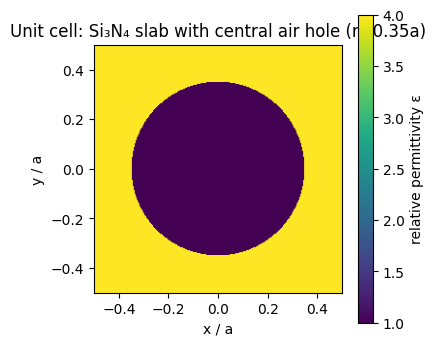

In [3]:
eps_map = slab_eps_map('Si3N4', radius=0.35, hole_material='air', resolution=256)
plt.figure(figsize=(4, 4))
plt.imshow(eps_map, extent=[-0.5, 0.5, -0.5, 0.5], origin='lower')
plt.colorbar(label='relative permittivity ε')
plt.title('Unit cell: Si₃N₄ slab with central air hole (r=0.35a)')
plt.xlabel('x / a'); plt.ylabel('y / a')
plt.show()

## 3. Simulate one design → a CD spectrum


- **Normalized frequency.** RCWA works in `f̃ = a/λ`; the physical wavelength
  enters only through the lattice constant `a_nm`. Pick `a_nm` to place features
  in the 600–850 nm band.
- **Circular dichroism (transmission).** `CD = (T_RCP − T_LCP)/(T_RCP + T_LCP)`,
  in `[−1, 1]`. We excite with right/left circular polarization and read total
  transmission for each.
- **Cost.** The twisted bilayer scales as `(2N_m+1)^4` plane waves, so we use a
  small `N` and few wavelengths here. Production accuracy needs a converged `N_m`
  (Section 5).

We hand-pick a clearly twisted design so the CD is visibly non-zero.

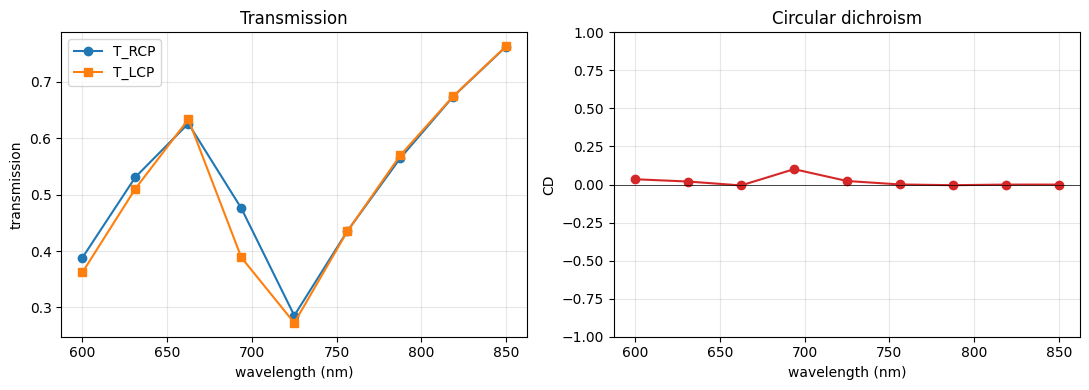

max |CD| = 0.10091472604902653


In [4]:
design = DesignParams(theta_deg=15.0, thickness=0.25, gap=0.10, radius=0.35)
wavelengths = np.linspace(600, 850, 9)   # coarse, for speed

res = simulate_design(design, wavelengths, a_nm=500.0, N=1,
                      slab_material='Si3N4', resolution=256)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(res.wavelengths_nm, res.T_RCP, 'o-', label='T_RCP')
ax1.plot(res.wavelengths_nm, res.T_LCP, 's-', label='T_LCP')
ax1.set(xlabel='wavelength (nm)', ylabel='transmission', title='Transmission')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(res.wavelengths_nm, res.cd, 'o-', color='C3')
ax2.axhline(0, color='k', lw=0.5)
ax2.set(xlabel='wavelength (nm)', ylabel='CD', title='Circular dichroism', ylim=(-1, 1))
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('max |CD| =', float(np.max(np.abs(res.cd))))

## 4. Physics sanity checks

Two checks we never skip:

1. **Energy conservation.** Our media are lossless (real `ε`), so `R + T = 1`.
   In RCWA the scattering matrix is unitary *by construction* for lossless media,
   so the residual `|1 − (R+T)|` is ~machine-zero at **any** `N_m`. That makes it
   a great *bug* detector — but **not** a convergence test (that's Section 5).
2. **Symmetry.** Two untwisted C₄ᵥ layers are achiral → **CD ≈ 0**. Twisting
   breaks the symmetry to C₄ and turns CD on. If an untwisted bilayer shows large
   CD, something is wrong.

In [5]:
print(f'energy residual |1-(R+T)| (max over grid): {res.energy_residual().max():.2e}')

untwisted = DesignParams(theta_deg=0.0, thickness=0.25, gap=0.10, radius=0.35)
res0 = simulate_design(untwisted, wavelengths, a_nm=500.0, N=1, resolution=256)
print(f'max |CD| untwisted (theta=0): {np.max(np.abs(res0.cd)):.3e}   (expect ~0)')
print(f'max |CD| twisted  (theta=15): {np.max(np.abs(res.cd)):.3e}   (expect > 0)')

energy residual |1-(R+T)| (max over grid): 2.00e-15
max |CD| untwisted (theta=0): 5.683e-15   (expect ~0)
max |CD| twisted  (theta=15): 1.009e-01   (expect > 0)


## 5. Choosing the truncation `N_m` (the convergence study)

`N_m` (the solver's `N=M`) sets both accuracy and cost. Smaller twist angles fold
a larger moiré supercell and higher index contrast (a-Si) mixes more harmonics —
both need a **larger** `N_m`. Too small silently poisons the data; too large makes
the dataset unaffordable (`(2N_m+1)^4`).

`data_generation/convergence_study.py` measures this: for representative
(material, twist) points it sweeps `N` and compares each spectrum to the
highest-`N` reference. A design is **converged** if a *smaller* `N` already
matches the reference; otherwise it is flagged **needs_higher_N** (confirm in a
later, more expensive run). The result is a `theta → N_m` policy that
`generate_dataset.py` applies per design (`data_generation/convergence.py`).

The cell below loads the study output if you've run it
(`python -m data_generation.convergence_study`).

materials tested: ['Si3N4', 'TiO2', 'aSi']
policy material : Si3N4
validated for theta >= 8.0 deg

per (material, angle):
   Si3N4 theta=   8 -> N*=2 [converged]

recommended theta -> N_m policy:
  theta >=    8 -> N_m = 2


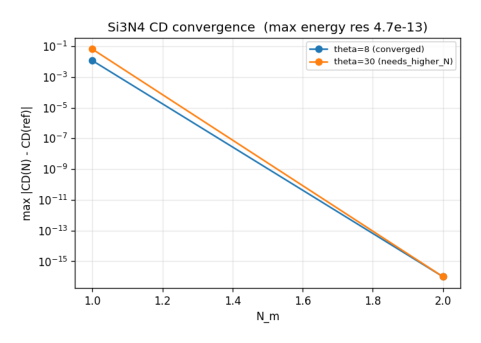

In [6]:
summ_path = os.path.join(ROOT, 'datasets', 'convergence', 'convergence_summary.json')
if os.path.exists(summ_path):
    with open(summ_path) as f:
        summ = json.load(f)
    print('materials tested:', summ['config']['slabs'])
    print('policy material :', summ['config']['policy_material'])
    print('validated for theta >=', summ['config'].get('policy_validated_above_deg'), 'deg')
    print()
    print('per (material, angle):')
    for d in sorted(summ['per_design'], key=lambda d: (d['material'], d['params']['theta_deg'])):
        if d['part'] != 'A':
            continue
        print(f"  {d['material']:>6s} theta={d['params']['theta_deg']:>4g} -> N*={d['n_star']} [{d['status']}]")
    print()
    print('recommended theta -> N_m policy:')
    for r in summ['recommended_policy']:
        lb = ' (lower bound)' if r.get('lower_bound') else ''
        print(f"  theta >= {r['theta_min']:>4g} -> N_m = {r['N_m']}{lb}")
    img = os.path.join(ROOT, 'datasets', 'convergence', "convergence_" + summ['config']['policy_material'] + '.png')
    if os.path.exists(img):
        from matplotlib import image as mpimg
        plt.figure(figsize=(6, 4.2)); plt.imshow(mpimg.imread(img)); plt.axis('off'); plt.show()
else:
    print('No convergence study found yet. Run:')
    print('  python -m data_generation.convergence_study')

## 6. Generating a dataset shard

Putting it together, the CLI samples many designs, simulates each (using the
per-twist `N_m` policy), and writes a **shard** to `datasets/`:

```bash
# tiny smoke run (seconds):
python -m data_generation.generate_dataset --smoke

# a real shard:
python -m data_generation.generate_dataset --n 200 --a-nm 500 \
    --lam-min 600 --lam-max 850 --n-lam 51 --seed 0 --shard shard000
```

Each shard writes: `raw/<shard>.npz` (full solver output), `processed/<shard>.npz`
(normalized `X` and CD target `Y`), `<shard>_xscaler.npz` (the feature scaler, so
inference uses the identical transform), and `<shard>_metadata.json` (full
provenance: `N_m` policy, grids, materials, seed, timing).

The cell below loads whatever shard you have and previews it.

loaded shard000.npz
X (designs, params): (4, 4)
Y (designs, wavelengths): (4, 11)
N_m: 1 | a_nm: 500.0 | slab: Si3N4


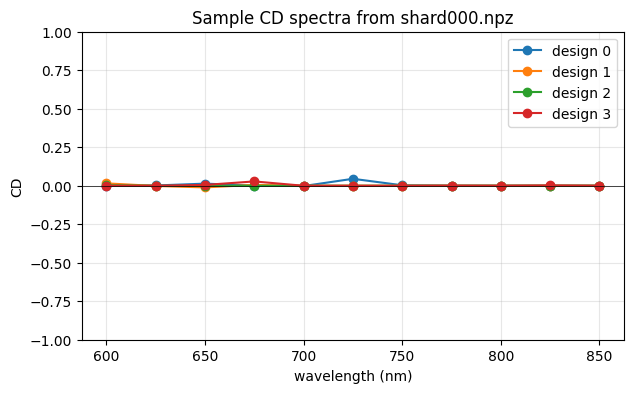

In [7]:
proc = os.path.join(ROOT, 'datasets', 'processed')
shards = sorted(glob.glob(os.path.join(proc, '*.npz')))
shards = [s for s in shards if not s.endswith('_xscaler.npz')]
if shards:
    shard = shards[0]
    data = np.load(shard)
    print('loaded', os.path.basename(shard))
    print('X (designs, params):', data['X'].shape)
    print('Y (designs, wavelengths):', data['Y'].shape)
    meta_path = shard.replace('.npz', '_metadata.json')
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            meta = json.load(f)
        print('N_m:', meta.get('N_m'), '| a_nm:', meta.get('a_nm'),
              '| slab:', meta.get('slab_material'))
    wl = data['wavelengths_nm']
    plt.figure(figsize=(7, 4))
    for i in range(min(4, data['Y'].shape[0])):
        plt.plot(wl, data['Y'][i], 'o-', label=f'design {i}')
    plt.axhline(0, color='k', lw=0.5)
    plt.xlabel('wavelength (nm)'); plt.ylabel('CD'); plt.ylim(-1, 1)
    plt.title(f'Sample CD spectra from {os.path.basename(shard)}')
    plt.legend(); plt.grid(alpha=0.3); plt.show()
else:
    print('No shard found. Generate one with:')
    print('  python -m data_generation.generate_dataset --smoke')

## Recap & what's next

Full Stage-1 loop: **sample → build unit cell → simulate CD →
sanity-check → choose `N_m` → compile a shard**. The output is a 
`(X, CD-spectrum)` dataset with persisted scalers and metadata.

**Next (Stage 2):** train a forward surrogate `X → CD spectrum` (an MLP baseline)
that replaces the solver with sub-second inference. **Stage 3:** invert it —
map a *target* CD spectrum back to a design, re-verifying every proposal in
RCWA-4D. See `README.md` for the full plan.